# Data Understanding - Yousician Open Dataset

El dataset contiene interacciones de estudiantes dentro de una plataforma de aprendizaje musical. Cada registro representa una actividad realizada por un usuario durante la práctica de una canción o ejercicio.

El objetivo inicial es comprender los patrones de práctica, desempeño y evolución temporal antes de realizar la preparación de datos para el modelo predictivo.

## Dataset source

Fuente:
Yousician Open Dataset

Descripción:
Dataset generado a partir de interacciones anonimizadas de estudiantes
en una plataforma de aprendizaje musical.

Unidad de observación:
Una interacción estudiante-ejercicio.

## 1. Importación de librerías

Se utilizan librerías de análisis de datos y visualización. Además, se define una función de lectura incremental porque el archivo original es grande y contiene una columna `events_data` con JSON anidado que no es necesaria para esta exploración inicial.

In [1]:
import json
import os
from pathlib import Path

MPLCONFIGDIR = Path("../.matplotlib_cache")
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR.resolve())

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Carga del dataset original

El archivo original se encuentra en formato JSON y cada fila representa una interacción. Para la exploración se excluye `events_data`, porque contiene detalles granulares de eventos musicales y aumenta considerablemente el tamaño en memoria.

In [2]:
RAW_PATH = Path("../data/raw/yousician_ukulele.json")

def stream_json_array(path, chunk_size=1024 * 1024):
    """Lee objetos desde un JSON grande con arreglo top-level sin cargar todo el archivo."""
    decoder = json.JSONDecoder()
    buffer = ""
    started = False

    with path.open("r", encoding="utf-8") as file:
        while True:
            chunk = file.read(chunk_size)
            if not chunk:
                break

            buffer += chunk

            while True:
                buffer = buffer.lstrip()

                if not started:
                    if not buffer:
                        break
                    if buffer[0] != "[":
                        raise ValueError("El archivo no tiene un arreglo JSON como estructura principal")
                    buffer = buffer[1:]
                    started = True
                    continue

                buffer = buffer.lstrip()
                if not buffer:
                    break
                if buffer[0] == ",":
                    buffer = buffer[1:]
                    continue
                if buffer[0] == "]":
                    return

                try:
                    item, idx = decoder.raw_decode(buffer)
                except json.JSONDecodeError:
                    break

                yield item
                buffer = buffer[idx:]

records = []
for record in stream_json_array(RAW_PATH):
    record.pop("events_data", None)
    records.append(record)

df_raw = pd.DataFrame(records)
df_raw.head()

,user_id,song_id,exercise_id,days_since_signup,song_type,difficulty_level,session_index,play_mode,chords_evaluated,chords_successful,notes_evaluated,notes_successful,time_playing,is_played_in_full,exit_status,exercise_part_index
0,uSJBJX,sd1DR_,eEz_Ci,0.001181,yousician_song,0,29,play,1,1,0,0,0,t,quit,0
1,uSJBJX,sz6O_i,eS84w4,0.006157,yousician_song,1,29,play,0,0,108,108,83,t,succeeded,3
2,uSJBJX,sz6O_i,eS84w4,0.006157,yousician_song,1,29,play,0,0,108,108,83,t,succeeded,2
3,uSJBJX,sz6O_i,eS84w4,0.006157,yousician_song,1,29,play,0,0,108,108,83,t,succeeded,1
4,uSJBJX,sz6O_i,eS84w4,0.006157,yousician_song,1,29,play,0,0,108,108,83,t,succeeded,0


## 3. Dimensiones iniciales

In [3]:
df_raw.shape

(415461, 16)

In [5]:
print(f"Numero de registros/interacciones: {df_raw.shape[0]:,}")
print(f"Numero de variables disponibles: {df_raw.shape[1]:,}")

Numero de registros/interacciones: 415,461
Numero de variables disponibles: 16


## 4. Variables disponibles

In [8]:
df_raw.columns.tolist()

['user_id',
 'song_id',
 'exercise_id',
 'days_since_signup',
 'song_type',
 'difficulty_level',
 'session_index',
 'play_mode',
 'chords_evaluated',
 'chords_successful',
 'notes_evaluated',
 'notes_successful',
 'time_playing',
 'is_played_in_full',
 'exit_status',
 'exercise_part_index']

## 5. Tipos de datos

Se revisan los tipos de datos para detectar variables numéricas, categóricas e identificadores.

In [7]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 415461 entries, 0 to 415460
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   user_id              415461 non-null  str    
 1   song_id              415461 non-null  str    
 2   exercise_id          415461 non-null  str    
 3   days_since_signup    415461 non-null  float64
 4   song_type            415461 non-null  str    
 5   difficulty_level     415461 non-null  int64  
 6   session_index        415461 non-null  int64  
 7   play_mode            415461 non-null  str    
 8   chords_evaluated     415461 non-null  int64  
 9   chords_successful    415461 non-null  int64  
 10  notes_evaluated      415461 non-null  int64  
 11  notes_successful     415461 non-null  int64  
 12  time_playing         415461 non-null  int64  
 13  is_played_in_full    415461 non-null  str    
 14  exit_status          415461 non-null  str    
 15  exercise_part_index  415461 

In [9]:
df_raw.dtypes

user_id                    str
song_id                    str
exercise_id                str
days_since_signup      float64
song_type                  str
difficulty_level         int64
session_index            int64
play_mode                  str
chords_evaluated         int64
chords_successful        int64
notes_evaluated          int64
notes_successful         int64
time_playing             int64
is_played_in_full          str
exit_status                str
exercise_part_index      int64
dtype: object

## 6. Usuarios únicos

Como el objetivo del proyecto es predecir si un estudiante mejora, es importante confirmar cuántos usuarios existen y recordar que el dataset original no está a nivel estudiante, sino a nivel interacción.

In [10]:
unique_users = df_raw["user_id"].nunique()
unique_users

1000

In [11]:
print(f"Usuarios únicos: {unique_users:,}")
print(f"Interacciones promedio por usuario: {df_raw.shape[0] / unique_users:.2f}")

Usuarios únicos: 1,000
Interacciones promedio por usuario: 415.46


## 7. Actividad por estudiante

Se analiza cuántas interacciones registra cada estudiante. Esto permite observar diferencias en intensidad de uso y posibles usuarios con poca actividad.

In [12]:
activity_by_student = (
    df_raw.groupby("user_id")
    .agg(
        total_interactions=("exercise_id", "count"),
        total_time_playing=("time_playing", "sum"),
        active_days=("days_since_signup", lambda x: x.astype(int).nunique()),
        sessions=("session_index", "nunique"),
        songs_practiced=("song_id", "nunique"),
        exercises_practiced=("exercise_id", "nunique")
    )
    .sort_values("total_interactions", ascending=False)
)

activity_by_student.head()

,total_interactions,total_time_playing,active_days,sessions,songs_practiced,exercises_practiced
user_id,,,,,,
ueBMwx,1258,275698,21,31,162,211
uaPgmy,1257,176281,15,38,70,83
uxddKK,1247,190432,25,44,103,124
upLcCH,1232,213900,28,52,112,147
u6lCae,1216,160233,23,44,138,175


In [13]:
activity_by_student.describe()

,total_interactions,total_time_playing,active_days,sessions,songs_practiced,exercises_practiced
count,1000.000000,1.000000e+03,1000.000000,1000.00000,1000.000000,1000.000000
mean,415.461000,4.752977e+04,13.417000,18.55100,43.787000,49.926000
std,253.871501,5.636063e+04,4.838028,8.09722,20.236876,25.428274
min,98.000000,4.068000e+03,2.000000,3.00000,4.000000,4.000000
25%,225.500000,1.935100e+04,10.000000,13.00000,30.000000,32.000000
50%,340.500000,3.244700e+04,13.000000,17.00000,41.000000,45.000000
75%,520.000000,5.536600e+04,16.000000,22.00000,54.000000,62.000000
max,1258.000000,1.011474e+06,31.000000,65.00000,162.000000,211.000000


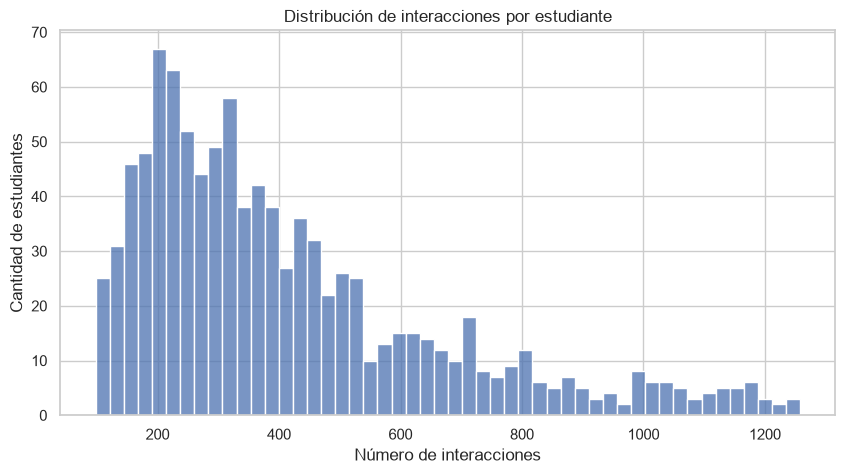

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(activity_by_student["total_interactions"], bins=50)
plt.title("Distribución de interacciones por estudiante")
plt.xlabel("Número de interacciones")
plt.ylabel("Cantidad de estudiantes")
plt.show()

## 8. Evolución temporal

La variable `days_since_signup` permite ordenar la actividad del estudiante en el tiempo. Esta variable es clave para separar el periodo inicial del periodo posterior y evitar fuga de información.

In [15]:
df_raw["days_since_signup"].describe()

count    415461.000000
mean         11.862070
std           8.999818
min           0.001181
25%           3.958623
50%          10.027083
75%          19.012697
max          30.999954
Name: days_since_signup, dtype: float64

In [16]:
df_raw["activity_day"] = df_raw["days_since_signup"].astype(int)

temporal_activity = (
    df_raw.groupby("activity_day")
    .agg(
        interactions=("user_id", "count"),
        active_users=("user_id", "nunique"),
        total_time_playing=("time_playing", "sum")
    )
    .reset_index()
)

temporal_activity.head(15)

,activity_day,interactions,active_users,total_time_playing
0,0,35347,830,2850343
1,1,26733,629,2549047
2,2,22602,601,2388179
3,3,20637,566,2125303
4,4,19485,555,2137738
5,5,19499,536,2060139
6,6,18388,547,2108123
7,7,15156,490,1671249
8,8,14176,487,1594299
9,9,15178,484,1950282


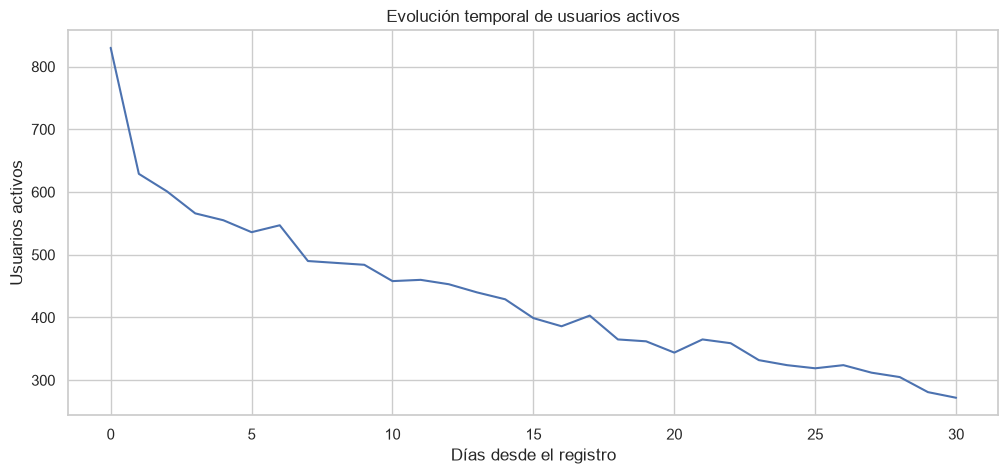

In [17]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=temporal_activity, x="activity_day", y="active_users")
plt.title("Evolución temporal de usuarios activos")
plt.xlabel("Días desde el registro")
plt.ylabel("Usuarios activos")
plt.show()

## 9. Métrica inicial de desempeño musical

Para evaluar si existe una métrica que represente desempeño musical, se crea `note_accuracy`, definida como la proporción de notas exitosas sobre notas evaluadas.

Esta métrica responde a la pregunta:

> ¿Existe una métrica que represente desempeño musical?

In [18]:
df_raw["note_accuracy"] = (
    df_raw["notes_successful"] /
    df_raw["notes_evaluated"]
)

In [19]:
df_raw["note_accuracy"].describe()

count    240906.000000
mean          0.780841
std           0.206917
min           0.000000
25%           0.695652
50%           0.838415
75%           0.932584
max           1.000000
Name: note_accuracy, dtype: float64

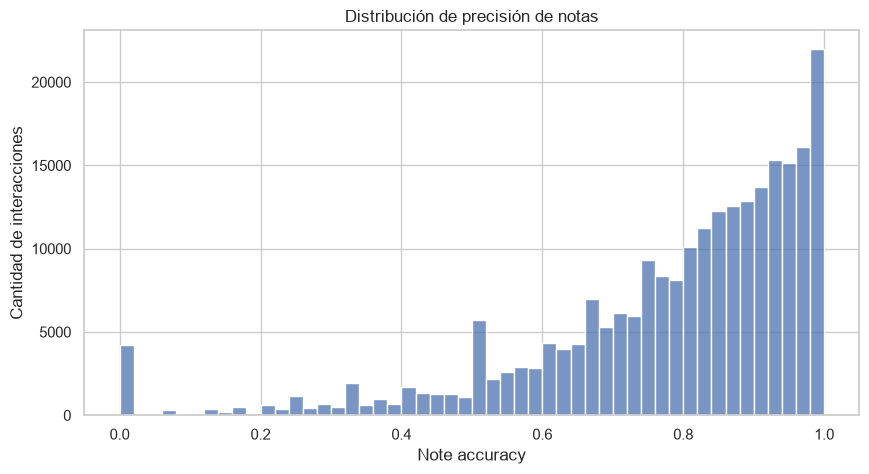

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(df_raw["note_accuracy"].dropna(), bins=50)
plt.title("Distribución de precisión de notas")
plt.xlabel("Note accuracy")
plt.ylabel("Cantidad de interacciones")
plt.show()

La variable `note_accuracy` sí representa una medida directa de desempeño musical, ya que compara las notas tocadas correctamente contra las notas evaluadas. Sin embargo, debe tratarse con cuidado: cuando `notes_evaluated` es cero, la métrica queda indefinida, por lo que esos casos no deben interpretarse como desempeño bajo.

## 10. Revisión de variables categóricas relevantes

Se revisan algunas variables categóricas que ayudan a entender el comportamiento del usuario durante la práctica.

Estas variables permiten entender el comportamiento del estudiante:
- play_mode: modalidad de práctica utilizada.
- exit_status: si completó o abandonó una actividad.
- is_played_in_full: indicador de compromiso con el ejercicio.

In [21]:
df_raw["play_mode"].value_counts(dropna=False)

play_mode
play        384109
practice     31352
Name: count, dtype: int64

In [22]:
df_raw["exit_status"].value_counts(dropna=False)

exit_status
succeeded    251388
restarted     89997
unknown       31352
quit          28255
failed        14469
Name: count, dtype: int64

In [23]:
df_raw["is_played_in_full"].value_counts(dropna=False)

is_played_in_full
t    365557
f     49904
Name: count, dtype: int64

## 11. Calidad inicial de datos: duplicados y valores nulos

In [27]:
df_raw.duplicated().sum()

np.int64(6647)

In [28]:
duplicate_key_columns = [
    "user_id", "song_id", "exercise_id", "days_since_signup",
    "session_index", "exercise_part_index", "play_mode", "exit_status",
    "notes_evaluated", "notes_successful", "chords_evaluated",
    "chords_successful", "time_playing", "is_played_in_full"
]

df_raw.duplicated(subset=duplicate_key_columns).sum()

np.int64(6647)

In [29]:
df_raw.isna().sum().sort_values(ascending=False)

note_accuracy          174555
song_id                     0
activity_day                0
exercise_part_index         0
exit_status                 0
is_played_in_full           0
time_playing                0
notes_successful            0
notes_evaluated             0
user_id                     0
chords_evaluated            0
play_mode                   0
session_index               0
difficulty_level            0
song_type                   0
days_since_signup           0
exercise_id                 0
chords_successful           0
dtype: int64

In [ ]:
zero_evaluation_summary = pd.Series({
    "notes_evaluated_zero": (df_raw["notes_evaluated"] == 0).sum(),
    "chords_evaluated_zero": (df_raw["chords_evaluated"] == 0).sum(),
    "notes_and_chords_evaluated_zero": (
        (df_raw["notes_evaluated"] == 0) &
        (df_raw["chords_evaluated"] == 0)
    ).sum()
})

zero_evaluation_summary

notes_evaluated_zero               174555
chords_evaluated_zero              230567
notes_and_chords_evaluated_zero      3289
dtype: int64

Los duplicados deben analizarse con cuidado porque el dataset está a nivel de interacción. Algunas filas repetidas pueden representar reintentos, reinicios o registros equivalentes de una misma parte del ejercicio. Además, los valores indefinidos en métricas como `note_accuracy` aparecen cuando `notes_evaluated` es cero; esto no implica necesariamente ausencia de datos, sino que en esa interacción no hubo notas evaluadas.

Por tanto, estas observaciones se documentan en Data Understanding

## 12. Ventanas temporales para el modelo predictivo

Para el proyecto de Machine Learning, las variables predictoras deben construirse usando únicamente información inicial del estudiante. Por ello, se propone separar:

- **Periodo inicial:** primeros 7 días de actividad.
- **Periodo posterior:** días 15 a 30.

Esta separación permite crear una variable objetivo basada en evolución temporal sin utilizar información futura dentro de las variables predictoras.

In [24]:
initial_period = df_raw[(df_raw["days_since_signup"] >= 0) & (df_raw["days_since_signup"] < 7)]
future_period = df_raw[(df_raw["days_since_signup"] >= 15) & (df_raw["days_since_signup"] <= 30)]

print(f"Interacciones en primeros 7 días: {len(initial_period):,}")
print(f"Usuarios en primeros 7 días: {initial_period['user_id'].nunique():,}")
print(f"Interacciones en días 15 a 30: {len(future_period):,}")
print(f"Usuarios en días 15 a 30: {future_period['user_id'].nunique():,}")

Interacciones en primeros 7 días: 162,691
Usuarios en primeros 7 días: 945
Interacciones en días 15 a 30: 138,624
Usuarios en días 15 a 30: 911


## 13. Limitaciones encontradas

Durante la exploración inicial se identificaron las siguientes consideraciones:

- El dataset original está a nivel de interacción, no de estudiante.
- Un mismo usuario aparece múltiples veces a lo largo del tiempo.
- Las variables de identificación (`user_id`, `song_id`, `exercise_id`) no deben utilizarse directamente como predictores.
- Fue necesario crear variables agregadas por estudiante.
- La variable objetivo debía construirse usando evolución temporal para evitar predecir el rendimiento actual con información futura.
- La métrica `note_accuracy` no se puede calcular cuando `notes_evaluated` es cero.
- Algunas variables pueden tener valores muy concentrados o sesgados por usuarios con alta frecuencia de práctica.
- La preparación final debe conservar `user_id` solo como identificador y excluir identificadores de canciones o ejercicios como variables predictoras.

## 14. Conclusión de Data Understanding

La exploración muestra que el dataset contiene información suficiente para construir variables de práctica, desempeño y comportamiento a nivel estudiante. La presencia de variables temporales permite separar el periodo inicial del periodo posterior, lo cual es fundamental para definir una variable objetivo de mejora sin fuga de información.

La métrica `note_accuracy` funciona como una aproximación interpretable del desempeño musical, aunque requiere tratamiento de valores indefinidos cuando no existen notas evaluadas. Por ello, en la fase de preparación de datos se deben agregar las interacciones por usuario y construir el objetivo `Performance_Improvement` comparando el desempeño inicial contra el desempeño posterior.